In [1]:
#scientific computing
#skala półlogarytmiczna
# podwójna logarytmiczna
#numpy, matplotlib

#sprawozdanie
#Temat
#tematy zadań
# argumentacja i fragmenty kodu
# wykresy tabele liczby
# wnioski
#bibliografia

#sprawozdanie pdf
# rozwiązanie każde jako osobny plik (nie zipować)

In [1]:
from typing import Callable
import numpy as np
import matplotlib.pyplot as plt
epsilon = np.finfo(float).eps

In [23]:
x = 1.0
fun = np.tan
h_array = 10.0 ** -np.arange(0, 17)

In [3]:
exact_d1 = 1.0 + np.tan(x) ** 2
exact_d2 = 2.0 * np.tan(x) * (1.0 + np.tan(x) ** 2)
exact_d3 = (2.0 + 6.0 * np.tan(x) ** 2) * (1.0 + np.tan(x) ** 2)

In [ ]:
def deriv_forward(x: float, h: float, func: Callable):
    return (func(x + h) - func(x)) / h

def deriv_central(x: float, h: float, func: Callable):
    return (func(x + h) - func(x - h)) / (2.0 * h)

In [24]:
%matplotlib inline
x = 1
fun = np.tan
our_res = np.array([deriv_forward(x,h,fun) for h in h_array])
true_res = 1+ exact_d1
M = exact_d2
truncation_error_array = M*h_array/2
rounding_error_array = 2*epsilon/h_array
computational_error_array = truncation_error_array+rounding_error_array
h_min_formula = 2*np.sqrt(epsilon/M)
#relative_error = np.array([abs(res-true_res) for res in our_res])
#non_relative_error = np.array([abs(res-true_res)/abs(true_res) for res in our_res])

In [27]:
res_deriv_forward = np.array([deriv_forward(x, h, fun) for h in h_array])

relative_error_forward = np.array([abs(res - exact_d1) for res in res_deriv_forward])
non_relative_error_forward = np.array([abs(res - exact_d1) / abs(exact_d1) for res in res_deriv_forward])

M2_forward = abs(exact_d2)

numerical_error_forward = 2.0 * epsilon / h_array
truncation_error_forward = M2_forward * h_array / 2.0
computational_error_forward = truncation_error_forward + numerical_error_forward

h_min_forward = 2.0 * np.sqrt(epsilon / M2_forward)

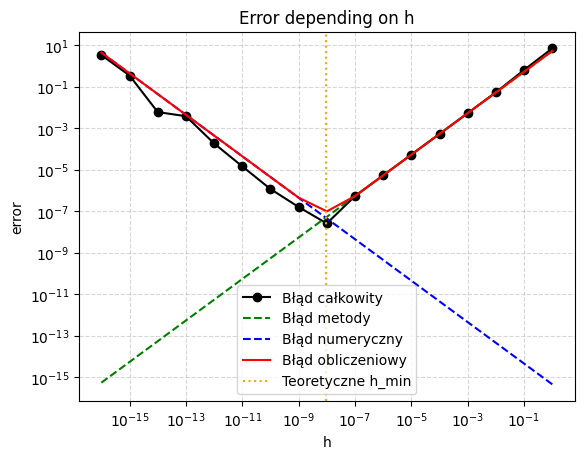

In [ ]:
plt.loglog(h_array, relative_error_forward, 'ko-', label='Błąd całkowity')
plt.loglog(h_array, truncation_error_forward, 'g--', label='Błąd metody')
plt.loglog(h_array, numerical_error_forward, 'b--', label='Błąd numeryczny')
plt.loglog(h_array, computational_error_forward, 'r-', label='Błąd obliczeniowy')
plt.axvline(h_min_forward, color='orange', linestyle=':', label='Teoretyczne h_min')
plt.title("Error depending on h")
plt.xlabel("h")
plt.ylabel("error")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

In [ ]:
res_deriv_central = np.array([deriv_central(x, h, fun) for h in h_array])

relative_error_central = np.array([abs(res - exact_d1) for res in res_deriv_central])
non_relative_error_central = np.array([abs(res - exact_d1) / abs(exact_d1) for res in res_deriv_central])


In [9]:
print(f'{ res_deriv_forward = }')
print(f'{ relative_error_forward = }')
print(f'{ non_relative_error_forward = }')

print(f'{ res_deriv_central = }')
print(f'{ relative_error_central = }')
print(f'{ non_relative_error_central = }')

 res_deriv_forward = array([-3.74244759e+00, -2.27508254e+01, -1.05065512e-02, -3.90467922e-03,
        2.19847055e-04, -1.16070115e-06, -8.09070890e-07, -9.22136935e-08,
       -1.75897023e-08, -1.53091099e-07, -1.02303148e-10, -2.95791468e-11,
       -1.20099614e-12, -7.03189765e-14,  1.10071891e-14, -1.58931308e-15,
       -2.80258116e-16])
 relative_error_forward = array([ 7.16796641, 26.17634424,  3.43602537,  3.4294235 ,  3.42529897,
        3.42551998,  3.42551963,  3.42551891,  3.42551884,  3.42551897,
        3.42551882,  3.42551882,  3.42551882,  3.42551882,  3.42551882,
        3.42551882,  3.42551882])
 non_relative_error_forward = array([2.09251993, 7.6415707 , 1.00306714, 1.00113988, 0.99993582,
       1.00000034, 1.00000024, 1.00000003, 1.00000001, 1.00000004,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        ])
 res_deriv_central = array([3.5230072 , 3.42646416, 3.42552827, 3.42551892, 3.42551882,
       3.42551882, 3.425518

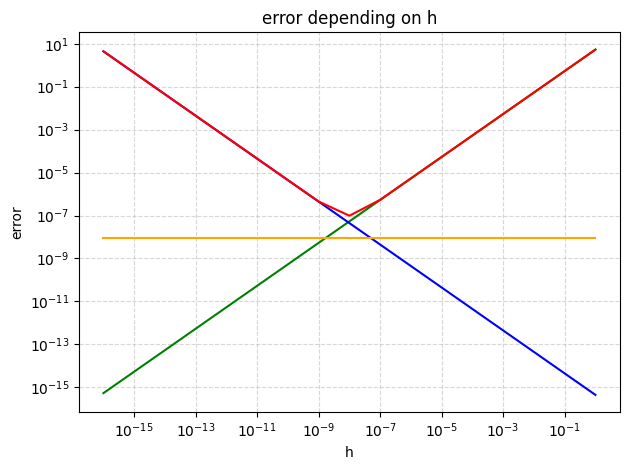

In [38]:
plt.loglog(h_array,truncation_error_array,color="green")
plt.loglog(h_array,rounding_error_array,color="blue")
plt.loglog(h_array,computational_error_array,color="red")
plt.loglog(h_array,np.array([h_min_formula for _ in range(len(h_array))]),color="orange")
plt.xlabel("h")
plt.ylabel("error")
plt.title("error depending on h")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()